In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
from google.colab import drive
from sklearn.model_selection import train_test_split    # For splitting data into train and test sets
from sklearn.metrics import confusion_matrix            # Evaluates model performance with correct/incorrect predictions
from sklearn.metrics import accuracy_score              # Measures model accuracy
from sklearn.preprocessing import StandardScaler        # Scales features for better model performance
from sklearn.linear_model import LogisticRegression     # For creating and training a logistic regression model
from sklearn.metrics import f1_score                    # Evaluates model performance using the F1 score (balance of precision and recall)

In [ ]:
drive.mount('/content/drive')
# Loading datasets
dataset = pd.read_csv('/content/diabetes (1).csv')
dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Category
0,6,148,72,35,0,33.6,0.627,50,1,yes
1,1,85,66,29,0,26.6,0.351,31,0,no
2,8,183,64,0,0,23.3,0.672,32,1,yes
3,1,89,66,23,94,28.1,0.167,21,0,no
4,0,137,40,35,168,43.1,2.288,33,1,yes
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,no
764,2,122,70,27,0,36.8,0.340,27,0,no
765,5,121,72,23,112,26.2,0.245,30,0,no
766,1,126,60,0,0,30.1,0.349,47,1,yes


In [ ]:
print("Number of column:", dataset.shape[1])
print("Number of row:", dataset.shape[0])
print("Features are:", dataset.columns.tolist())
#to show how much column , row and lable i have

Number of column: 10
Number of row: 768
Features are: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Category']


In [ ]:
# all attributes except index 9 Category is input
X=dataset.iloc[:,[0,1,2,3,4,5,6,7]]
dataset= dataset.drop('Category', axis=1)
# • Category (Class/target Attribute) at index 9 (the output)
y=dataset.iloc[:,8]
dataset = dataset.rename(columns={'Outcome': 'diagnoses'})

print("Features:",X.keys())  # Features of dataset
print("Predicted:",y.name)

Features: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Predicted: Outcome


#Data Cleaning


In [ ]:
# Create a copy of the dataset to make it esey to run
data = dataset.copy()

# Specify the columns to replace 0 values
impute_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 values with (NaN) in the specified columns
data[impute_columns] = data[impute_columns].replace(0, np.nan)

# Fill NaN values with the median in the specified columns
data[impute_columns] = data[impute_columns].fillna(data[impute_columns].median())

# Display the updated data
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diagnoses
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
min_values = data.min()
print(min_values)
# we want the max to know the lowest values to find the limits

Pregnancies                  0.000
Glucose                     44.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.078
Age                         21.000
diagnoses                    0.000
dtype: float64


In [ ]:
max_values = data.max()
print(max_values)
# we want the max to know the highest values to find the limits

Pregnancies                  17.00
Glucose                     199.00
BloodPressure               122.00
SkinThickness                99.00
Insulin                     846.00
BMI                          67.10
DiabetesPedigreeFunction      2.42
Age                          81.00
diagnoses                     1.00
dtype: float64


To determine the reasonable limits, we took the lowest and highest values for each variable as follows:

Glucose:

* Lowest: 35 / Highest: 500

BloodPressure:

* Lowest: 35 /Highest: 250

SkinThickness:

* Lowest: 5 /Highest: 70

Insulin:

* Lowest: 10 \Highest: 1000

BMI:

* Lowest: 10 / Highest: 100

DiabetesPedigreeFunction:


* Lowest: 0.05 / Highest: 3.5


We have looked for reasonable limits and these the sources.

https://www.mayoclinic.org/



In [ ]:
DeletSk = data[data['SkinThickness'] >= 70]
data  = data.drop (DeletSk.index)
# we found that SkinThickness has element that a greter than reasonable limits by useing the max func , so we drop it
DeletBl = data[data['BloodPressure'] <= 35]
# we found that BloodPressure has element that a smaaller than reasonable limits by useing the min func , so we drop it
data  = data.drop (DeletBl.index)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diagnoses
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [ ]:
data.duplicated().sum()
#to show you there is no duplicated in evry row in the data

0

# Data Transformation
Feature engineering: Create new features that might help improve model performance

In [ ]:
# we save the Boundary in list
bins = [0, 125, 200]  #Boundary values ​​for categories
labels = ['Normal', 'Diabetes']  # name of the categories
#Create a new column containing categories
data['Status'] = pd.cut(data['Glucose'], bins=bins, labels=labels, right=False)
# show
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diagnoses,Status
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Diabetes
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Normal
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Diabetes
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Normal
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Diabetes


In [ ]:
# We want all the element numbers, so I changed it
# I didn't change it in the beginning because I wanted to show you the levels of Diabetes."
data['Status'] = data['Status'].map({'Normal': 0, 'Diabetes': 1})
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diagnoses,Status
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100)
# We use the library to split the data into training and test sets
# this is the real method we used : train_test_split(X, y, test_size=0.20, random_state=100)

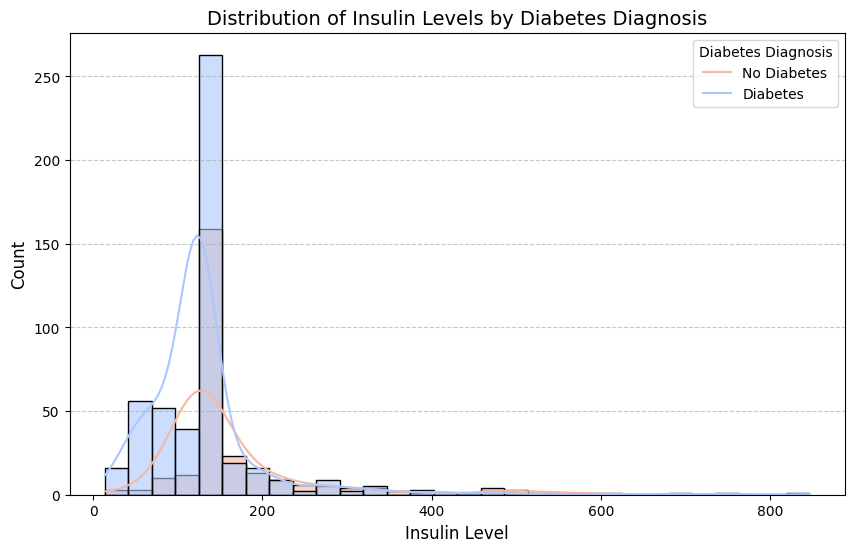

In [ ]:
 #Create a histogram to show the distribution of insulin levels
# hue='diagnoses' colors the data based on diabetes status
# kde=True adds a kernel density estimate (smooth curve) for better visualization
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Insulin', hue='diagnoses', bins=30, kde=True, palette='coolwarm', alpha=0.6)
# Set labels and title
plt.xlabel('Insulin Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Insulin Levels by Diabetes Diagnosis', fontsize=14)
plt.legend(title="Diabetes Diagnosis", labels=['No Diabetes', 'Diabetes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

•	Low insulin levels (<50) are common in both diabetic and non-diabetic individuals but could indicate Type 1 Diabetes or insulin deficiency.
	•	Moderate insulin levels (50–200) are typically seen in normal metabolism or early stages of Type 2 Diabetes.
	•	High insulin levels (>200, up to 800+) are mostly found in diabetics, likely due to insulin resistance or medication use.
	•	The presence of both very low and very high insulin levels in diabetics suggests a mix of Type 1 and Type 2 diabetes cases in the dataset.

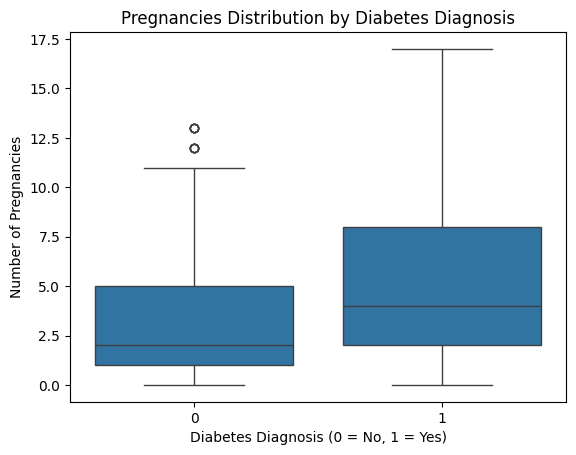

In [ ]:
# Create a boxplot to show the distribution of pregnancies based on diabetes diagnosis
sns.boxplot(data=data, x='diagnoses', y='Pregnancies')
# Set labels and title
plt.xlabel('Diabetes Diagnosis (0 = No, 1 = Yes)')
plt.ylabel('Number of Pregnancies')
plt.title('Pregnancies Distribution by Diabetes Diagnosis')
plt.show()

    Higher pregnancy count is associated with a higher likelihood of diabetes, which might suggest a link between reproductive history and diabetes risk

<ipython-input-112-d708a8bf4f7c>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=data, x='diagnoses', y='Age', ci="sd", palette="Blues")
<ipython-input-112-d708a8bf4f7c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='diagnoses', y='Age', ci="sd", palette="Blues")


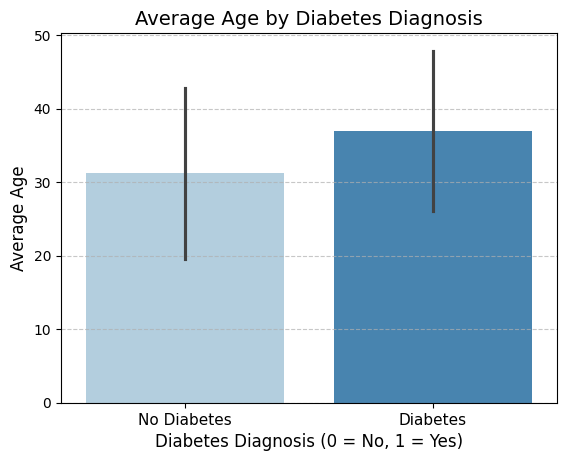

In [ ]:
#Drawing the barplot
sns.barplot(data=data, x='diagnoses', y='Age', ci="sd", palette="Blues")
# Set labels and title
plt.xlabel('Diabetes Diagnosis (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Age', fontsize=12)
plt.title('Average Age by Diabetes Diagnosis', fontsize=14)
# Improve the appearance of the drawing
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'], fontsize=11)
plt.show()

Age is a contributing factor to diabetes with older individuals having a higher likelihood of being diagnosed However, since the standard deviation is large, age alone is not a definitive predictor, and younger individuals can still develop diabetes

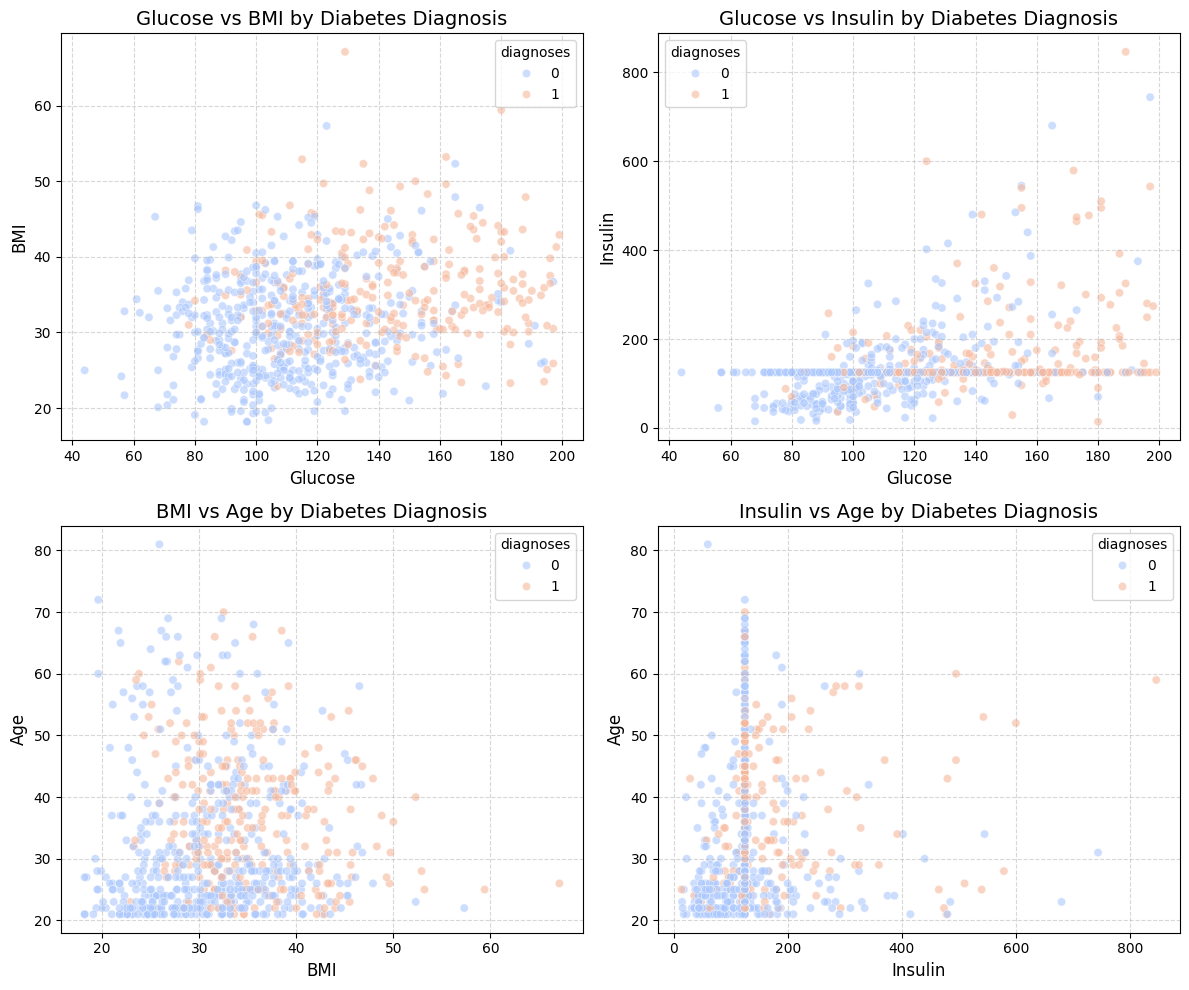

In [ ]:
# Define selected pairs of variables for scatter plots
feature_pairs = [('Glucose', 'BMI'), ('Glucose', 'Insulin'), ('BMI', 'Age'), ('Insulin', 'Age')]

plt.figure(figsize=(12, 10))
# Loop through each pair of features and create scatter plots
for i, (x_feature, y_feature) in enumerate(feature_pairs, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=data, x=x_feature, y=y_feature, hue="diagnoses", alpha=0.6, palette="coolwarm")
        # Set labels and title
    plt.xlabel(x_feature, fontsize=12)
    plt.ylabel(y_feature, fontsize=12)
    plt.title(f"{x_feature} vs {y_feature} by Diabetes Diagnosis", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


1- Glucose vs BMI High glucose levels are strongly associated with diabetes, but BMI alone does not clearly separate diabetics from non-diabetics.
2- Glucose vs Insulin,Glucose and insulin together can indicate diabetes, but the variation suggests different insulin response mechanisms among patients.
3- Age vs BMI , Age and BMI alone are not strong predictors of diabetes, but high BMI could still be a contributing factor.
4-Age vs Insulin , Age does not significantly influence insulin levels, but high insulin levels are more common among diabetics.

In [ ]:
print(data.describe())
# Prints descriptive statistics for numerical columns in the dataset.
# These include metrics like count, mean,
#std (standard deviation), min, max, and quartiles (25%, 50%, 75%).
mode= y.mode()
mode
# Calculates the mode (the most frequently occurring value) of the variable 'y'.
# The result is printed,'Outcome' has a mode of "0", it indicates that "0" occurs most frequently in the dataset.

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   764.000000  764.000000     764.000000     764.000000  764.000000   
mean      3.858639  121.668848      72.564136      29.001309  140.973822   
std       3.372997   30.340860      11.801651       8.415566   86.467151   
min       0.000000   44.000000      38.000000       7.000000   14.000000   
25%       1.000000  100.000000      64.000000      25.000000  124.250000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  128.250000   
max      17.000000  199.000000     122.000000      63.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age   diagnoses  
count  764.000000                764.000000  764.000000  764.000000  
mean    32.414660                  0.471974   33.229058    0.348168  
std      6.830733                  0.331994   11.733660    0.476702  
min     18.200000                  

,Outcome
0,0


In [ ]:
numerical_features=data.select_dtypes(include=['float64', 'int64'])
# Selects only the numerical columns (data types: float64 and int64) from the dataset.
# This step ensures we only work with numerical data for calculations such as variance.
variance1=numerical_features.var()
# Variance measures how much the values in a column are spread out from their mean.
# A high variance indicates a larger spread, while a low variance
#suggests the values are closer to the mean.
variance1

,0
Pregnancies,11.377107
Glucose,920.567783
BloodPressure,139.278974
SkinThickness,70.821755
Insulin,7476.568121
BMI,46.658920
DiabetesPedigreeFunction,0.110220
Age,137.678788
diagnoses,0.227244


In [ ]:
std_dev = variance1 ** 0.5
std_dev

,0
Pregnancies,3.372997
Glucose,30.340860
BloodPressure,11.801651
SkinThickness,8.415566
Insulin,86.467151
BMI,6.830733
DiabetesPedigreeFunction,0.331994
Age,11.733660
diagnoses,0.476702


In [ ]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train_scaled, y_train)

# Predict and calculate F1 Score
y_pred = logistic_regression.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred)
#Show visualized test results
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
# Print the F1 Score
print("Model name: Logistic Regression")
print(f"F1 Score: {f1:.4f}")

Model name: Logistic Regression
F1 Score: 0.5684


In [ ]:
df.head()


,Actual,Predicted
173,0,0
253,0,0
207,1,1
737,0,0
191,0,0
